Note: This jupyter notebook will use Fairlearn library, below cell helps to instll Fairlearn library.

In [1]:
#Install Fairlearn library
%pip install -q fairlearn

Note: you may need to restart the kernel to use updated packages.


# Part 2.2 Learning Curve

## Part 2.2.1 Load Datasets and Remove Duplicate Records

Here we load the 2 datasets used in Individual Task 1.

- Dataset1 - 'Default of Credit Card Clients' from website https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients
- Dataset2 - 'Give Me Some Credit' from website https://www.kaggle.com/competitions/GiveMeSomeCredit/overview

Below are the libraries to be used in this jupyter notebook.

In [2]:
# Libraries to be used in this jupyter notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import learning_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score)
from fairlearn.metrics import (MetricFrame, selection_rate, false_positive_rate, false_negative_rate, count)
from IPython.display import display

Before loading the datasets, let's retrieve the directory where the notebook is running.

In [3]:
# Retrieve the directory where the notebook is running
dirname = os.getcwd()

Here to load the first dataset into jupyetr notebook.

In [4]:
# Define first dataset file name to be loaded
filename_dataset1 = 'default of credit card clients.xls'
# Define full file path
full_path = os.path.join(dirname, filename_dataset1)
# Load the first dataset file to dataframe1, skip first row and load attributes from second row of the file
dataframe1 = pd.read_excel(full_path, header=1)
# Drop column 'ID'
dataframe1 = dataframe1.drop(columns=['ID'])

After loading the dataset, let's update the attribute names for all columns.

In [5]:
# Update attribute names of dataframe1
dataframe1.columns = ["CREDIT_LIMIT", "GENDER", "EDUCATION_LEVEL", "MARITAL_STATUS", "AGE",
                      "REPAYMENT_STATUS_1", "REPAYMENT_STATUS_2", "REPAYMENT_STATUS_3", 
                      "REPAYMENT_STATUS_4", "REPAYMENT_STATUS_5", "REPAYMENT_STATUS_6",
                      "BILL_STATEMENT_AMOUNT_1", "BILL_STATEMENT_AMOUNT_2", "BILL_STATEMENT_AMOUNT_3",
                      "BILL_STATEMENT_AMOUNT_4", "BILL_STATEMENT_AMOUNT_5", "BILL_STATEMENT_AMOUNT_6",
                      "AMOUNT_PAID_1", "AMOUNT_PAID_2", "AMOUNT_PAID_3", 
                      "AMOUNT_PAID_4", "AMOUNT_PAID_5", "AMOUNT_PAID_6", "DEFAULT"]

Here to inspect the dimension of first dataset.

In [6]:
# Check the dimension of dataframe1
print('The dimension of first dataset is:', dataframe1.shape)

The dimension of first dataset is: (30000, 24)


Here to drop fully duplicated records and retain first instance only.

In [7]:
# Drop duplicate records and keep the first instance only
dataframe1 = dataframe1.drop_duplicates(keep = 'first').reset_index(drop = True)

After dropping duplicated records, let's inspect the dimension of first dataset again.

In [8]:
# Check the dimension of first dataset again
print('The dimension of first dataset is:', dataframe1.shape)

The dimension of first dataset is: (29965, 24)


Next, we load the second dataset into jupyetr notebook.

In [9]:
# Define second dataset file name to be loaded
filename_dataset2 = 'cs-training.csv'
# Define full file path
full_path = os.path.join(dirname, filename_dataset2)
# Load the second dataset file to dataframe2 with header (attributes)
dataframe2 = pd.read_csv(full_path, sep = ',', decimal = '.', header = 0)
# Remove first column (ID)
dataframe2 = dataframe2.iloc[:, 1:]

After loading the dataset, let's update the attribute names for all columns.

In [10]:
# Update attribute names of dataframe2
dataframe2.columns = ["DELINQUENCY", "UTILIZATION", "AGE", "NO_OF_TIMES_PAST_30_59", "DEBT_TO_INCOME_RATIO", 
                      "MONTHLY_INCOME", "NO_OF_OPEN_LOAN_CREDIT_LINE", "NO_OF_TIMES_PAST_90", 
                      "NO_OF_MORTGAGE_LOAN", "NO_OF_TIMES_PAST_60_89", "NO_OF_DEPENDENTS"]

Here to inspect the dimension of second dataset.

In [11]:
# Check the dimension of dataframe2
print('The dimension of second dataset is:', dataframe2.shape)

The dimension of second dataset is: (150000, 11)


Here to drop fully duplicated records and retain first instance only.

In [12]:
# Drop duplicate records and keep the first instance only
dataframe2 = dataframe2.drop_duplicates(keep = 'first').reset_index(drop = True)

After dropping duplicated records, let's inspect the dimension of second dataset again.

In [13]:
# Check the dimension of second dataset again
print('The dimension of second dataset is:', dataframe2.shape)

The dimension of second dataset is: (149391, 11)


## Part 2.2.2 Learning Curve Analysis for Both Datasets

Here to define variables `X_dataframe1`, `y_dataframe1`, `X_dataframe2` and `y_dataframe2` with following definition:
- `X_dataframe1`: Dataframe to hold all features in first dataset
- `y_dataframe1`: Dataframe to hold all targets in first dataset
- `X_dataframe2`: Dataframe to hold all features in second dataset
- `y_dataframe2`: Dataframe to hold all targets in second dataset

In [14]:
# Define dataframe `X_dataframe1' to hold all features in first dataset
X_dataframe1 = dataframe1.drop(columns = ['DEFAULT'])
# Define dataframe `y_dataframe1' to hold all targets in first dataset
y_dataframe1 = dataframe1['DEFAULT']
# Define dataframe `X_dataframe2' to hold all features in second dataset
X_dataframe2 = dataframe2.drop(columns = ['DELINQUENCY'])
# Define dataframe `y_dataframe2' to hold all targets in second dataset
y_dataframe2 = dataframe2['DELINQUENCY']

Here to define seed number, number of stratified K-fold and create stratified K-fold object accordingly.

In [15]:
# Define seed number using variable `seed_number`
seed_number = 100
# Define number of stratified K-fold cross validation using variable `number_of_folds`
number_of_folds = 5
# Create stratified K-fold object
stratified_k_fold = StratifiedKFold(n_splits = number_of_folds, random_state = seed_number, shuffle = True)

Here to define Decision Tree model and Random Forest model respectively.

In [16]:
# Create Decision Tree model
model_decision_tree = DecisionTreeClassifier(criterion = 'gini', random_state = seed_number)
# Create Random Forest model
model_random_forest = RandomForestClassifier(n_estimators = 200, random_state = seed_number)

Now, we perform learning curve analysis on the first dataset using Decision Tree model.

In [17]:
# Perform learning curve analysis on the first dataset using Decision Tree model
train_sizes_dataframe1_decision_tree, train_scores_dataframe1_decision_tree, validation_scores_dataframe1_decision_tree = learning_curve(
    estimator = model_decision_tree, X = X_dataframe1, y = y_dataframe1,
    cv = stratified_k_fold, scoring = 'f1', train_sizes = np.linspace(0.1, 1.0, 10), n_jobs = -1
)
# Calculate the mean training F1 score across cross-validation folds
train_mean_dataframe1_decision_tree = np.mean(train_scores_dataframe1_decision_tree, axis=1)
# Calculate the mean validation F1 score across cross-validation folds
validation_mean_dataframe1_decision_tree = np.mean(validation_scores_dataframe1_decision_tree, axis=1)

Also, we perform learning curve analysis on the first dataset using Random Forest model.

In [18]:
# Perform learning curve analysis on the first dataset using Random Forest model
train_sizes_dataframe1_random_forest, train_scores_dataframe1_random_forest, validation_scores_dataframe1_random_forest = learning_curve(
    estimator = model_random_forest, X = X_dataframe1, y = y_dataframe1,
    cv = stratified_k_fold, scoring = 'f1', train_sizes = np.linspace(0.1, 1.0, 10), n_jobs = -1
)
# Calculate the mean training F1 score across cross-validation folds
train_mean_dataframe1_random_forest = np.mean(train_scores_dataframe1_random_forest, axis=1)
# Calculate the mean validation F1 score across cross-validation folds
validation_mean_dataframe1_random_forest = np.mean(validation_scores_dataframe1_random_forest, axis=1)

The learning curves for first dataset is displayed as follows.

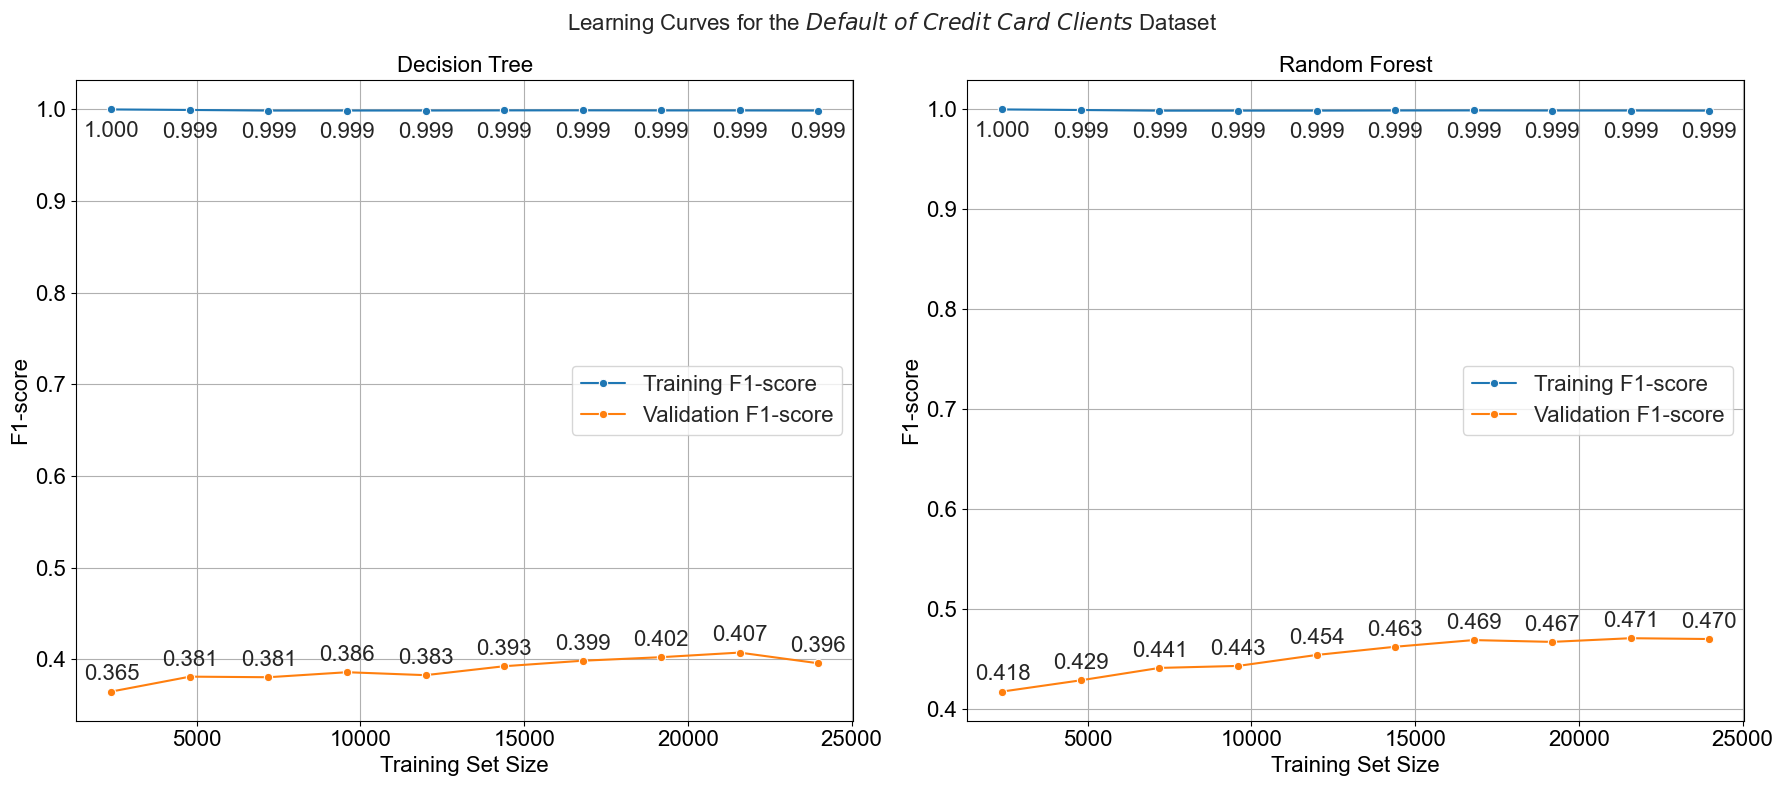

In [19]:
# Plot the learning curves for dataset 'Default of Credit Card Clients'
fig, axes = plt.subplots(1, 2, figsize = (18,8))
sns.set_theme(style="whitegrid")
# Learning curve through Decision Tree model
sns.lineplot(x = train_sizes_dataframe1_decision_tree, y = train_mean_dataframe1_decision_tree, 
             marker = 'o', label = 'Training F1-score', ax = axes[0])
sns.lineplot(x = train_sizes_dataframe1_decision_tree, y = validation_mean_dataframe1_decision_tree, 
             marker = 'o', label = 'Validation F1-score', ax = axes[0])
axes[0].set_xlabel('Training Set Size', fontsize = 16)
axes[0].set_ylabel('F1-score', fontsize = 16)
axes[0].set_title('Decision Tree', fontsize = 16)
axes[0].tick_params(axis='both', labelsize = 16)
axes[0].legend(loc="center right", fontsize = 16)
axes[0].grid(True)
# Display values for training data
for x, y in zip(train_sizes_dataframe1_decision_tree, train_mean_dataframe1_decision_tree):
    axes[0].annotate(f'{y:.3f}', (x, y), textcoords = "offset points", xytext = (0, -20), ha = 'center', fontsize = 16)
# Display values for validation data
for x, y in zip(train_sizes_dataframe1_decision_tree, validation_mean_dataframe1_decision_tree):
    axes[0].annotate(f'{y:.3f}', (x, y), textcoords = "offset points", xytext = (0, 8), ha = 'center', fontsize = 16)

# Learning curve through Random Forest model
sns.lineplot(x = train_sizes_dataframe1_random_forest, y = train_mean_dataframe1_random_forest, 
             marker = 'o', label = 'Training F1-score', ax = axes[1])
sns.lineplot(x = train_sizes_dataframe1_random_forest, y = validation_mean_dataframe1_random_forest, 
             marker = 'o', label = 'Validation F1-score', ax = axes[1])
axes[1].set_xlabel('Training Set Size', fontsize = 16)
axes[1].set_ylabel('F1-score', fontsize = 16)
axes[1].set_title('Random Forest', fontsize = 16)
axes[1].tick_params(axis='both', labelsize = 16)
axes[1].legend(loc="center right", fontsize = 16)
axes[1].grid(True)
# Display values for training data
for x, y in zip(train_sizes_dataframe1_random_forest, train_mean_dataframe1_random_forest):
    axes[1].annotate(f'{y:.3f}', (x, y), textcoords = "offset points", xytext = (0, -20), ha = 'center', fontsize = 16)
# Display values for validation data
for x, y in zip(train_sizes_dataframe1_random_forest, validation_mean_dataframe1_random_forest):
    axes[1].annotate(f'{y:.3f}', (x, y), textcoords = "offset points", xytext = (0, 8), ha = 'center', fontsize = 16)

# Display learning curve
fig.suptitle(r'Learning Curves for the $\it{Default\ of\ Credit\ Card\ Clients}$ Dataset', fontsize = 16)
plt.tight_layout(rect = [0, 0, 1, 1])
plt.show()

Next, we perform learning curve analysis on the second dataset using Decision Tree model.

In [20]:
# Perform learning curve analysis on the second dataset using Decision Tree model
train_sizes_dataframe2_decision_tree, train_scores_dataframe2_decision_tree, validation_scores_dataframe2_decision_tree = learning_curve(
    estimator = model_decision_tree, X = X_dataframe2, y = y_dataframe2,
    cv = stratified_k_fold, scoring = 'f1', train_sizes = np.linspace(0.1, 1.0, 10), n_jobs = -1
)
# Calculate the mean training F1 score across cross-validation folds
train_mean_dataframe2_decision_tree = np.mean(train_scores_dataframe2_decision_tree, axis=1)
# Calculate the mean validation F1 score across cross-validation folds
validation_mean_dataframe2_decision_tree = np.mean(validation_scores_dataframe2_decision_tree, axis=1)

Also, we perform learning curve analysis on the second dataset using Random Forest model.

In [21]:
# Perform learning curve analysis on the second dataset using Random Forest model
train_sizes_dataframe2_random_forest, train_scores_dataframe2_random_forest, validation_scores_dataframe2_random_forest = learning_curve(
    estimator = model_random_forest, X = X_dataframe2, y = y_dataframe2,
    cv = stratified_k_fold, scoring = 'f1', train_sizes = np.linspace(0.1, 1.0, 10), n_jobs = -1
)
# Calculate the mean training F1 score across cross-validation folds
train_mean_dataframe2_random_forest = np.mean(train_scores_dataframe2_random_forest, axis=1)
# Calculate the mean validation F1 score across cross-validation folds
validation_mean_dataframe2_random_forest = np.mean(validation_scores_dataframe2_random_forest, axis=1)

The learning curves for second dataset is displayed as follows.

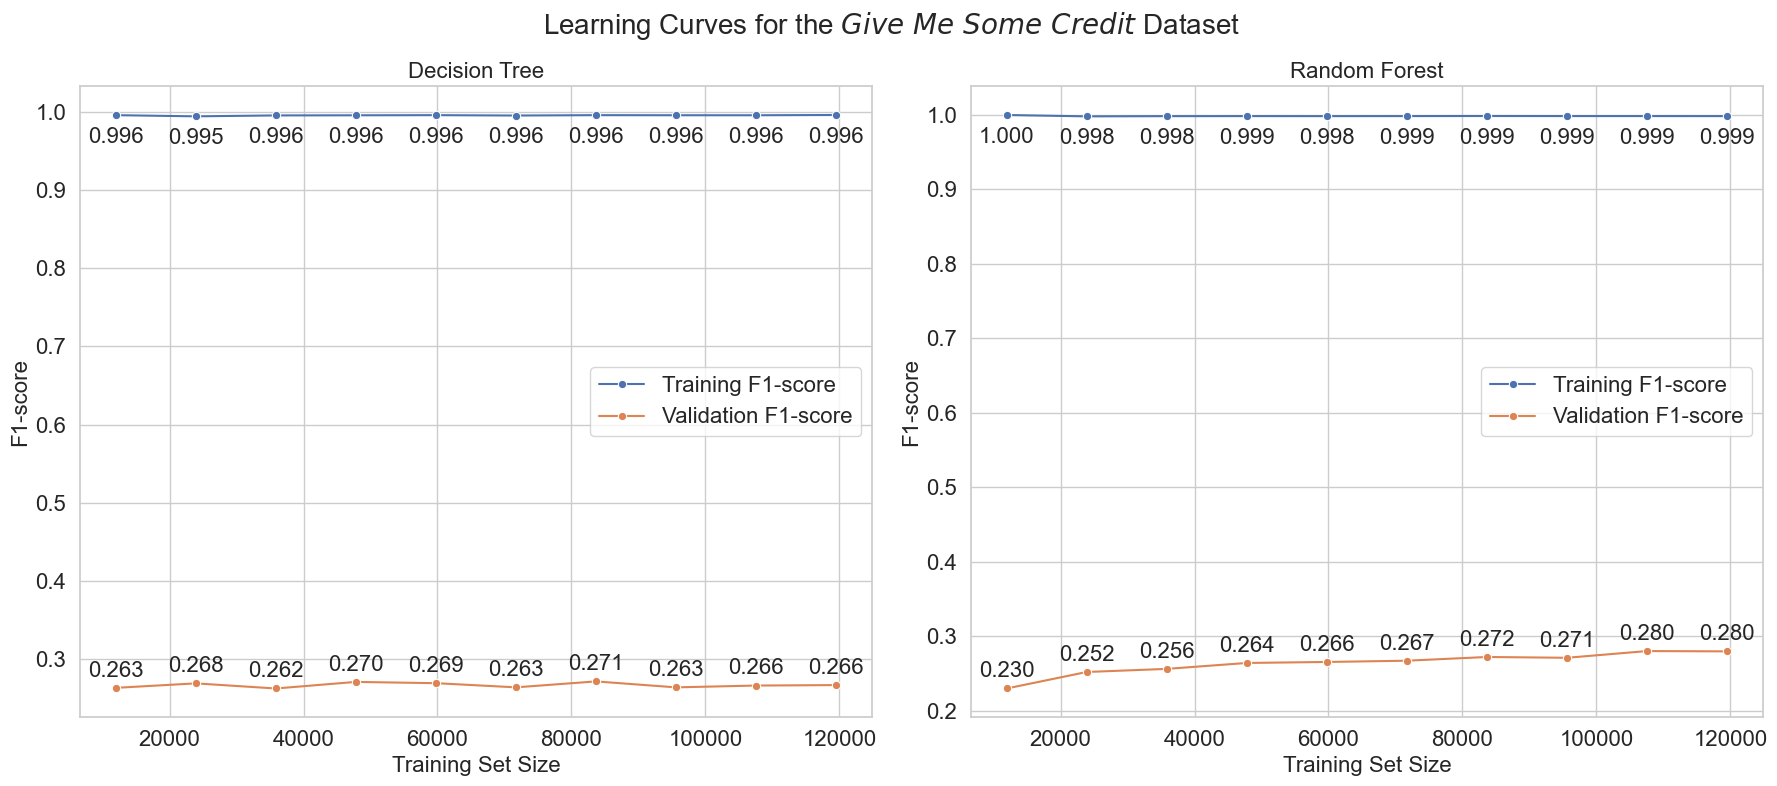

In [22]:
# Plot the learning curves for dataset 'Give Me Some Credit'
fig, axes = plt.subplots(1, 2, figsize = (18,8))
sns.set_theme(style="whitegrid")
# Learning curve through Decision Tree model
sns.lineplot(x = train_sizes_dataframe2_decision_tree, y = train_mean_dataframe2_decision_tree, 
             marker = 'o', label = 'Training F1-score', ax = axes[0])
sns.lineplot(x = train_sizes_dataframe2_decision_tree, y = validation_mean_dataframe2_decision_tree, 
             marker = 'o', label = 'Validation F1-score', ax = axes[0])
axes[0].set_xlabel('Training Set Size', fontsize = 16)
axes[0].set_ylabel('F1-score', fontsize = 16)
axes[0].set_title('Decision Tree', fontsize = 16)
axes[0].tick_params(axis='both', labelsize = 16)
axes[0].legend(loc="center right", fontsize = 16)
axes[0].grid(True)
# Display values for training data
for x, y in zip(train_sizes_dataframe2_decision_tree, train_mean_dataframe2_decision_tree):
    axes[0].annotate(f'{y:.3f}', (x, y), textcoords = "offset points", xytext = (0, -20), ha = 'center', fontsize = 16)
# Display values for validation data
for x, y in zip(train_sizes_dataframe2_decision_tree, validation_mean_dataframe2_decision_tree):
    axes[0].annotate(f'{y:.3f}', (x, y), textcoords = "offset points", xytext = (0, 8), ha = 'center', fontsize = 16)
    
# Learning curve through Random Forest model
sns.lineplot(x = train_sizes_dataframe2_random_forest, y = train_mean_dataframe2_random_forest, 
             marker = 'o', label = 'Training F1-score', ax = axes[1])
sns.lineplot(x = train_sizes_dataframe2_random_forest, y = validation_mean_dataframe2_random_forest, 
             marker = 'o', label = 'Validation F1-score', ax = axes[1])
axes[1].set_xlabel('Training Set Size', fontsize = 16)
axes[1].set_ylabel('F1-score', fontsize = 16)
axes[1].set_title('Random Forest', fontsize = 16)
axes[1].tick_params(axis='both', labelsize = 16)
axes[1].legend(loc="center right", fontsize = 16)
axes[1].grid(True)
# Display values for training data
for x, y in zip(train_sizes_dataframe2_random_forest, train_mean_dataframe2_random_forest):
    axes[1].annotate(f'{y:.3f}', (x, y), textcoords = "offset points", xytext = (0, -20), ha = 'center', fontsize = 16)
# Display values for validation data
for x, y in zip(train_sizes_dataframe2_random_forest, validation_mean_dataframe2_random_forest):
    axes[1].annotate(f'{y:.3f}', (x, y), textcoords = "offset points", xytext = (0, 8), ha = 'center', fontsize = 16)
    
# Display learning curve
fig.suptitle(r'Learning Curves for the $\it{Give\ Me\ Some\ Credit}$ Dataset', fontsize = 20)
plt.tight_layout(rect = [0, 0, 1, 1])
plt.show()

# Part 2.3 Observed Bias in Both Datasets 

Here adopted Microsoft Fairlearn to understand any observed bias in both datasets.

Before the analysis, let's define the model names to be used and the function to perform model prediction.

In [23]:
# Define model names to be used
model_names = ['Decision Tree', 'Random Forest']

# Define function to perform model prediction
def model_prediction(X_train, X_test, y_train, seed_number, model_name):
    # Define both Decision Tree Classification and Random Forest Classification models
    if model_name == 'Decision Tree':
        model = DecisionTreeClassifier(criterion = 'gini', random_state = seed_number)
    elif model_name == 'Random Forest':
        model = RandomForestClassifier(n_estimators = 200, random_state = seed_number)
    # Fit the model
    model.fit(X_train, y_train)
    # Generate predicted classification
    y_pre = model.predict(X_test)
    # Return predicted classification
    return y_pre

## Part 2.3.1 Analysis on First Dataset

For the first dataset 'Default of Credit Card Clients', let's inspect the attribute "GENDER".

Attribute "GENDER" referred the gender of the borrower.  Value "1" as male and "2" as female.

Here to display the frequencies of attribute "GENDER" for reference.

In [24]:
# Check frequency of attribute "GENDER"
dataframe1['GENDER'].value_counts()

GENDER
2    18091
1    11874
Name: count, dtype: int64

It is observed that the gender distribution is as follows:
- 11874 males
- 18091 females

Furthermore, let's calculate the proportion of gender distribution. 

In [25]:
# Check proportion of distribution of attribute "GENDER"
round(dataframe1['GENDER'].value_counts(normalize=True), 3)

GENDER
2    0.604
1    0.396
Name: proportion, dtype: float64

It is observed that the proportion of gender distribution is as follows:
- 39.6% males
- 60.4% females

Here to define the dictionary to store fairness result from both models.

In [26]:
# Define dictionary to store fairness result from both models for first dataset
fairness_results_dataframe1 = {
    'Decision Tree': {'y_true': [], 'y_pred': [], 'gender': []},
    'Random Forest': {'y_true': [], 'y_pred': [], 'gender': []}
}

Here to perform stratified K-fold cross-validation for both models using first dataset.

In [27]:
# Perform stratified 5-fold cross-validation and collect test-set predictions together with the corresponding gender groups
for train_index, test_index in stratified_k_fold.split(X_dataframe1, y_dataframe1):
    # Retrieve training feature set for the current fold
    X_train = X_dataframe1.iloc[train_index]
    # Retrieve testing feature set for the current fold
    X_test = X_dataframe1.iloc[test_index]
    # Retrieve training target set for the current fold
    y_train = y_dataframe1.iloc[train_index]
    # Retrieve testing target set for the current fold
    y_test = y_dataframe1.iloc[test_index]
    # Generate predictions for each model
    for model_name in model_names:
        # Generate predictions using the current model
        y_pred = model_prediction(X_train, X_test, y_train, seed_number, model_name)
        # Store true target values for the current model
        fairness_results_dataframe1[model_name]['y_true'].extend(y_test.tolist())
        # Store predicted target values for the current model
        fairness_results_dataframe1[model_name]['y_pred'].extend(y_pred.tolist())
        # Store gender values for the current model
        fairness_results_dataframe1[model_name]['gender'].extend(X_test['GENDER'].tolist())

Here to define the performance and fairness metrics using Decision Tree model for first dataset.

In [28]:
# Define classification performance and fairness-related metrics for Decision Tree model behaviour across gender groups
metrics_dataframe1_decision_tree = {'Accuracy': accuracy_score, 'Precision': precision_score, 'Recall': recall_score,
                                    'F1 Score': f1_score, 'False Positive Rate': false_positive_rate, 
                                    'False Negative Rate': false_negative_rate, 'Selection Rate': selection_rate}

Here to create a MetricFrame to evaluate Decision Tree model across gender groups for first dataset.

In [29]:
# Create a Fairlearn MetricFrame to compare overall and gender group specific Decision Tree model performance
metric_frame_dataframe1_decision_tree = MetricFrame(metrics = metrics_dataframe1_decision_tree, 
                                                    y_true = fairness_results_dataframe1['Decision Tree']['y_true'],
                                                    y_pred = fairness_results_dataframe1['Decision Tree']['y_pred'],
                                                    sensitive_features = fairness_results_dataframe1['Decision Tree']['gender']
                                                   )

Here to display the combined metrics table using Decision Tree model across gender groups for first dataset. 

In [30]:
# Retrieve overall metrics
overall_df = pd.DataFrame([metric_frame_dataframe1_decision_tree.overall])
# Add an "Overall" label to identify overall metrics
overall_df.insert(0, 'Group','Overall')
# Retrieve metrics for each gender group
by_group_df = metric_frame_dataframe1_decision_tree.by_group.reset_index()
# Rename sensitive feature column to Group
by_group_df = by_group_df.rename(columns = {by_group_df.columns[0]: 'Group'})
# Combine overall and gender-group metrics
combined_metrics_dataframe1_decision_tree = round(pd.concat([overall_df, by_group_df], ignore_index=True), 4)
# Replace gender codes with meaningful labels
combined_metrics_dataframe1_decision_tree['Group'] = combined_metrics_dataframe1_decision_tree['Group'].replace({1: 'Male', 2: 'Female'})
# Calculate absolute differences between the best-performing and worst-performing gender groups
dataframe1_decision_tree_disparity = (metric_frame_dataframe1_decision_tree.difference())
# Create disparity row
disparity_row = pd.DataFrame(
    [['Absolute Difference (Percentage Points)', *dataframe1_decision_tree_disparity.tolist()]],
    columns = combined_metrics_dataframe1_decision_tree.columns
)
# Add disparity row
combined_metrics_dataframe1_decision_tree = pd.concat([combined_metrics_dataframe1_decision_tree, disparity_row], ignore_index = True)
# Display combined metrics table with appropriate decimal formatting
display(combined_metrics_dataframe1_decision_tree
        .style.hide(axis = "index")
        .format("{:.4f}", subset = combined_metrics_dataframe1_decision_tree.columns[1:])
        .set_properties(**{'text-align': 'center'}))

Group,Accuracy,Precision,Recall,F1 Score,False Positive Rate,False Negative Rate,Selection Rate
Overall,0.7218,0.3811,0.4119,0.3959,0.1901,0.5881,0.2392
Male,0.6996,0.3853,0.4085,0.3965,0.2077,0.5915,0.2562
Female,0.7364,0.3779,0.4145,0.3954,0.1791,0.5855,0.2280
Absolute Difference (Percentage Points),0.0368,0.0073,0.0060,0.0012,0.0286,0.0060,0.0282


Here to define the performance and fairness metrics using Random Forest model for first dataset.

In [31]:
# Define classification performance and fairness-related metrics for Random Forest model behaviour across gender groups
metrics_dataframe1_random_forest = {'Accuracy': accuracy_score, 'Precision': precision_score, 'Recall': recall_score,
                                    'F1 Score': f1_score, 'False Positive Rate': false_positive_rate, 
                                    'False Negative Rate': false_negative_rate, 'Selection Rate': selection_rate}

Here to create a MetricFrame to evaluate Random Forest model across gender groups for first dataset.

In [32]:
# Create a Fairlearn MetricFrame to compare overall and gender group specific Random Forest model performance
metric_frame_dataframe1_random_forest = MetricFrame(metrics = metrics_dataframe1_random_forest, 
                                                    y_true = fairness_results_dataframe1['Random Forest']['y_true'],
                                                    y_pred = fairness_results_dataframe1['Random Forest']['y_pred'],
                                                    sensitive_features = fairness_results_dataframe1['Random Forest']['gender']
                                                   )

Here to display the combined metrics table using Random Forest model across gender groups for first dataset. 

In [33]:
# Retrieve overall metrics
overall_df = pd.DataFrame([metric_frame_dataframe1_random_forest.overall])
# Add an "Overall" label to identify overall metrics
overall_df.insert(0, 'Group','Overall')
# Retrieve metrics for each gender group
by_group_df = metric_frame_dataframe1_random_forest.by_group.reset_index()
# Rename sensitive feature column to Group
by_group_df = by_group_df.rename(columns = {by_group_df.columns[0]: 'Group'})
# Combine overall and gender-group metrics
combined_metrics_dataframe1_random_forest = round(pd.concat([overall_df, by_group_df], ignore_index=True), 4)
# Replace gender codes with meaningful labels
combined_metrics_dataframe1_random_forest['Group'] = combined_metrics_dataframe1_random_forest['Group'].replace({1: 'Male', 2: 'Female'})
# Calculate absolute differences between the best-performing and worst-performing gender groups
dataframe1_random_forest_disparity = (metric_frame_dataframe1_random_forest.difference())
# Create disparity row
disparity_row = pd.DataFrame(
    [['Absolute Difference (Percentage Points)', *dataframe1_random_forest_disparity.tolist()]],
    columns = combined_metrics_dataframe1_random_forest.columns
)
# Add disparity row
combined_metrics_dataframe1_random_forest = pd.concat([combined_metrics_dataframe1_random_forest, disparity_row], ignore_index = True)
# Display combined metrics table with appropriate decimal formatting
display(combined_metrics_dataframe1_random_forest
        .style.hide(axis="index")
        .format("{:.4f}", subset = combined_metrics_dataframe1_random_forest.columns[1:])
        .set_properties(**{'text-align': 'center'}))

Group,Accuracy,Precision,Recall,F1 Score,False Positive Rate,False Negative Rate,Selection Rate
Overall,0.8154,0.6439,0.3706,0.4704,0.0582,0.6294,0.1273
Male,0.7975,0.6368,0.3764,0.4732,0.0684,0.6236,0.1428
Female,0.8272,0.6495,0.3661,0.4683,0.0518,0.6339,0.1172
Absolute Difference (Percentage Points),0.0297,0.0127,0.0103,0.0049,0.0166,0.0103,0.0256


## Part 2.3.2 Analysis on Second Dataset

For the second dataset 'Give Me Some Credit', let's inspect the attribute "AGE".

Attribute "AGE" referred the age of the customer.  In order to better understand for any potrntial bias on this demographic attribute, records will be grouped into different age groups. 

Here to identify each record into different age groups.

In [34]:
# Convert numerical AGE into categorical age groups for fairness analysis
age_group_dataframe2 = pd.cut(
    X_dataframe2['AGE'],
    bins=[0, 17, 29, 39, 49, 59, np.inf],
    labels=['Unknown', '18-29', '30-39', '40-49', '50-59', '60+'],
    include_lowest=True
)

Here to display the frequencies of different age groups for reference.

In [35]:
# Check frequency of age_group_dataframe2
age_group_dataframe2.value_counts()

AGE
60+        48073
50-59      35231
40-49      34339
30-39      23138
18-29       8609
Unknown        1
Name: count, dtype: int64

It is not expected to have one record with unknown age.  Believed this is related to a record with missing age information.  Let's remove that record.

In [36]:
# Drop record with age smaller than 18 in second dataset
dataframe2 = dataframe2[dataframe2['AGE'] >= 18].reset_index(drop=True)

After dropping the record, let's inspect the dimension of the second dataset again.

In [37]:
# Check the dimension of second dataset again
print('The dimension of second dataset is:', dataframe2.shape)

The dimension of second dataset is: (149390, 11)


Now re-create respective dataframe to remove record with missing age information.

In [38]:
# Define dataframe `X_dataframe2' to hold all features in second dataset
X_dataframe2 = dataframe2.drop(columns = ['DELINQUENCY'])
# Define dataframe `y_dataframe2' to hold all targets in second dataset
y_dataframe2 = dataframe2['DELINQUENCY']
# Convert numerical AGE into categorical age groups for fairness analysis again
age_group_dataframe2 = pd.cut(
    X_dataframe2['AGE'],
    bins=[17, 29, 39, 49, 59, np.inf],
    labels=['18-29', '30-39', '40-49', '50-59', '60+'],
    include_lowest=True
)

Here to display the frequencies of different age groups for reference again.

In [39]:
# Check frequency of age_group_dataframe2
age_group_dataframe2.value_counts()

AGE
60+      48073
50-59    35231
40-49    34339
30-39    23138
18-29     8609
Name: count, dtype: int64

It is observed that the age group distribution is as follows:
- 8609 customers in age group 18-29
- 23138 customers in age group 30-39
- 34339 customers in age group 40-49
- 35231 customers in age group 50-59
- 48073 customers in age group 60+

Furthermore, let's calculate the proportion of age group distribution. 

In [40]:
# Check proportion of distribution of age_group_dataframe2
round(age_group_dataframe2.value_counts(normalize=True), 3)

AGE
60+      0.322
50-59    0.236
40-49    0.230
30-39    0.155
18-29    0.058
Name: proportion, dtype: float64

It is observed that the proportion of age group distribution is as follows:
- 5.8% customers in age group 18-29
- 15.5% customers in age group 30-39
- 23.0% customers in age group 40-49
- 23.6% customers in age group 50-59
- 32.2% customers in age group 60+

Here to define the dictionary to store fairness result from both models.

In [41]:
# Define dictionary to store fairness result from both models for second dataset
fairness_results_dataframe2 = {
    'Decision Tree': {'y_true': [], 'y_pred': [], 'age_group': []},
    'Random Forest': {'y_true': [], 'y_pred': [], 'age_group': []}
}

Here to perform stratified K-fold cross-validation for both models using second dataset.

In [42]:
# Perform stratified 5-fold cross-validation and collect test-set predictions together with the corresponding age groups
for train_index, test_index in stratified_k_fold.split(X_dataframe2, y_dataframe2):
    # Retrieve training feature set for the current fold
    X_train = X_dataframe2.iloc[train_index]
    # Retrieve testing feature set for the current fold
    X_test = X_dataframe2.iloc[test_index]
    # Retrieve training target set for the current fold
    y_train = y_dataframe2.iloc[train_index]
    # Retrieve testing target set for the current fold
    y_test = y_dataframe2.iloc[test_index]
    # Sensitive feature (age group) for TEST records only
    age_group_test_records = age_group_dataframe2.iloc[test_index]
    # Generate predictions for each model
    for model_name in model_names:
        # Generate predictions using the current model
        y_pred = model_prediction(X_train, X_test, y_train, seed_number, model_name)
        # Store true target values for the current model
        fairness_results_dataframe2[model_name]['y_true'].extend(y_test.tolist())
        # Store predicted target values for the current model
        fairness_results_dataframe2[model_name]['y_pred'].extend(y_pred.tolist())
        # Store age group values for the current model
        fairness_results_dataframe2[model_name]['age_group'].extend(age_group_test_records.tolist())

Here to define the performance and fairness metrics using Decision Tree model for second dataset.

In [43]:
# Define classification performance and fairness-related metrics for Decision Tree model behaviour across age groups
metrics_dataframe2_decision_tree = {'Accuracy': accuracy_score, 'Precision': precision_score, 'Recall': recall_score,
                                    'F1 Score': f1_score, 'False Positive Rate': false_positive_rate, 
                                    'False Negative Rate': false_negative_rate, 'Selection Rate': selection_rate}

Here to create a MetricFrame to evaluate Decision Tree model across age groups for second dataset.

In [44]:
# Create a Fairlearn MetricFrame to compare overall and age-group-specific Decision Tree model performance
metric_frame_dataframe2_decision_tree = MetricFrame(metrics = metrics_dataframe2_decision_tree, 
                                                    y_true = fairness_results_dataframe2['Decision Tree']['y_true'],
                                                    y_pred = fairness_results_dataframe2['Decision Tree']['y_pred'],
                                                    sensitive_features = fairness_results_dataframe2['Decision Tree']['age_group']
                                                   )

Here to display the combined metrics table using Decision Tree model across age groups for second dataset. 

In [45]:
# Retrieve overall metrics
overall_df = pd.DataFrame([metric_frame_dataframe2_decision_tree.overall])
# Add an "Overall" label to identify overall metrics
overall_df.insert(0, 'Group','Overall')
# Retrieve metrics for each age group
by_group_df = metric_frame_dataframe2_decision_tree.by_group.reset_index()
# Rename sensitive feature column to Group
by_group_df = by_group_df.rename(columns = {by_group_df.columns[0]: 'Group'})
# Combine overall and age group metrics
combined_metrics_dataframe2_decision_tree = round(pd.concat([overall_df, by_group_df], ignore_index=True), 4)
# Calculate absolute differences between the best-performing and worst-performing age groups
dataframe2_decision_tree_disparity = (metric_frame_dataframe2_decision_tree.difference())
# Create disparity row
disparity_row = pd.DataFrame(
    [['Absolute Difference (Percentage Points)', *dataframe2_decision_tree_disparity.tolist()]],
    columns = combined_metrics_dataframe2_decision_tree.columns
)
# Add disparity row
combined_metrics_dataframe2_decision_tree = pd.concat([combined_metrics_dataframe2_decision_tree, disparity_row], ignore_index = True)
# Display combined metrics table with appropriate decimal formatting
display(combined_metrics_dataframe2_decision_tree
        .style.hide(axis="index")
        .format("{:.4f}", subset = combined_metrics_dataframe2_decision_tree.columns[1:])
        .set_properties(**{'text-align': 'center'}))

Group,Accuracy,Precision,Recall,F1 Score,False Positive Rate,False Negative Rate,Selection Rate
Overall,0.8968,0.2543,0.2791,0.2661,0.0588,0.7209,0.0736
18-29,0.8291,0.3036,0.3353,0.3187,0.1040,0.6647,0.1316
30-39,0.8503,0.2756,0.2975,0.2861,0.0877,0.7025,0.1088
40-49,0.8760,0.2725,0.2879,0.2800,0.0702,0.7121,0.0885
50-59,0.8969,0.2365,0.2682,0.2514,0.0597,0.7318,0.0732
60+,0.9462,0.1848,0.2120,0.1975,0.0301,0.7880,0.0358
Absolute Difference (Percentage Points),0.1171,0.1188,0.1233,0.1212,0.0739,0.1233,0.0958


Here to define the performance and fairness metrics using Random Forest model for second dataset.

In [46]:
# Define classification performance and fairness-related metrics for Random Forest model behaviour across age groups
metrics_dataframe2_random_forest = {'Accuracy': accuracy_score, 'Precision': precision_score, 'Recall': recall_score,
                                    'F1 Score': f1_score, 'False Positive Rate': false_positive_rate, 
                                    'False Negative Rate': false_negative_rate, 'Selection Rate': selection_rate}

Here to create a MetricFrame to evaluate Random Forest model across age groups for second dataset.

In [47]:
# Create a Fairlearn MetricFrame to compare overall and age-group-specific Random Forest model performance
metric_frame_dataframe2_random_forest = MetricFrame(metrics = metrics_dataframe2_random_forest, 
                                                    y_true = fairness_results_dataframe2['Random Forest']['y_true'],
                                                    y_pred = fairness_results_dataframe2['Random Forest']['y_pred'],
                                                    sensitive_features = fairness_results_dataframe2['Random Forest']['age_group']
                                                   )

Here to display the combined metrics table using Random Forest model across age groups for second dataset. 

In [48]:
# Retrieve overall metrics
overall_df = pd.DataFrame([metric_frame_dataframe2_random_forest.overall])
# Add an "Overall" label to identify overall metrics
overall_df.insert(0, 'Group','Overall')
# Retrieve metrics for each age group
by_group_df = metric_frame_dataframe2_random_forest.by_group.reset_index()
# Rename sensitive feature column to Group
by_group_df = by_group_df.rename(columns = {by_group_df.columns[0]: 'Group'})
# Combine overall and age groups metrics
combined_metrics_dataframe2_random_forest = round(pd.concat([overall_df, by_group_df], ignore_index=True), 4)
# Calculate absolute differences between the best-performing and worst-performing age groups
dataframe2_random_forest_disparity = (metric_frame_dataframe2_random_forest.difference())
# Create disparity row
disparity_row = pd.DataFrame(
    [['Absolute Difference (Percentage Points)', *dataframe2_random_forest_disparity.tolist()]],
    columns = combined_metrics_dataframe2_random_forest.columns
)
# Add disparity row
combined_metrics_dataframe2_random_forest = pd.concat([combined_metrics_dataframe2_random_forest, disparity_row], ignore_index = True)
# Display combined metrics table with appropriate decimal formatting
display(combined_metrics_dataframe2_random_forest
        .style.hide(axis="index")
        .format("{:.4f}", subset = combined_metrics_dataframe2_random_forest.columns[1:])
        .set_properties(**{'text-align': 'center'}))

Group,Accuracy,Precision,Recall,F1 Score,False Positive Rate,False Negative Rate,Selection Rate
Overall,0.9354,0.5516,0.1897,0.2823,0.0111,0.8103,0.0230
18-29,0.8812,0.5036,0.2027,0.2891,0.0270,0.7973,0.0480
30-39,0.9038,0.5567,0.2229,0.3183,0.0199,0.7771,0.0404
40-49,0.9203,0.5648,0.2107,0.3069,0.0148,0.7893,0.0312
50-59,0.9375,0.5514,0.1697,0.2596,0.0095,0.8303,0.0199
60+,0.9695,0.5542,0.1193,0.1964,0.0031,0.8807,0.0067
Absolute Difference (Percentage Points),0.0884,0.0611,0.1036,0.1220,0.0239,0.1036,0.0413
